### Individual Homework

#### Enter your name here: Péter Ferencz

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Analysis of movies IMDB dataset**

We will look at a ***subset*** sample of movies, taken from the [Kaggle IMDB 5000 movie dataset](https://www.kaggle.com/carolzhangdc/imdb-5000-movie-dataset)

In [2]:
movies = pd.read_csv('../Data/movies.csv')
movies


,title,genre,director,year,duration,gross,budget,cast_facebook_likes,votes,reviews,rating
0,Avatar,Action,James Cameron,2009,178,760505847,237000000,4834,886204,3777,7.9
1,Titanic,Drama,James Cameron,1997,194,658672302,200000000,45223,793059,2843,7.7
2,Jurassic World,Action,Colin Trevorrow,2015,124,652177271,150000000,8458,418214,1934,7.0
3,The Avengers,Action,Joss Whedon,2012,173,623279547,220000000,87697,995415,2425,8.1
4,The Dark Knight,Action,Christopher Nolan,2008,152,533316061,185000000,57802,1676169,5312,9.0
...,...,...,...,...,...,...,...,...,...,...,...
2956,Locker 13,Thriller,Bruce Dellis,2014,95,2468,300000,2048,241,15,4.8
2957,The Ghastly Love of Johnny X,Comedy,Paul Bunnell,2012,106,2436,2000000,1611,344,113,5.7
2958,Detention of the Dead,Comedy,Alex Craig Mann,2012,87,1332,500000,2251,2038,49,4.6
2959,The Trials of Darryl Hunt,Crime,Ricki Stern,2006,106,1111,200000,2,771,21,7.7


Besides the obvious variables of `title`, `genre`, `director`, `year`, and `duration`, the rest of the variables are as follows:

-   `gross` : The gross earnings in the US box office, not adjusted for inflation
-   `budget`: The movie's budget
-   `cast_facebook_likes`: the number of facebook likes cast memebrs received
-   `votes`: the number of people who voted for (or rated) the movie in IMDB
-   `reviews`: the number of reviews for that movie
-   `rating`: IMDB average rating

**Produce a table with the count of movies by genre, ranked in descending order**


In [5]:
movie_count_per_genre = (
    movies
    .groupby('genre')
    .agg(
        count=('title', 'size')
    )
    .reset_index()
    .sort_values('count', ascending=False)
)

display(movie_count_per_genre)

,genre,count
4,Comedy,848
0,Action,738
7,Drama,498
1,Adventure,288
5,Crime,202
3,Biography,135
10,Horror,131
2,Animation,35
9,Fantasy,28
6,Documentary,25


**Produce a table with the average gross earning and budget (`gross` and `budget`) by genre. Calculate a variable `return_on_budget` which shows how many \$ did a movie make at the box office for each \$ of its budget. Ranked genres by this `return_on_budget` in descending order**

In [18]:
#Since I didn't understand clearly from the task that we should do the mean calculation before the group by or after, I decided to provide all the solutions.

# return_on_budget calculated per movie and the average calculation comes next
genre_rank_by_return = (
    movies
    .assign(
        return_on_budget=movies['gross'] / movies['budget']
    )
    .groupby('genre')
    .agg(
        return_on_budget_mean= ('return_on_budget', 'mean')
    )
    .reset_index()
    .sort_values('return_on_budget_mean', ascending=False)
)

display(genre_rank_by_return)

,genre,return_on_budget_mean
10,Horror,88.304785
3,Biography,22.280597
11,Musical,18.817819
8,Family,14.076490
6,Documentary,8.698550
16,Western,7.062800
9,Fantasy,6.681969
2,Animation,5.009095
4,Comedy,3.713990
12,Mystery,3.269397


In [ ]:
# the gross and budget means are calculated first, after that the reutrn_on_budget

genre_rank_by_return_2 = (
    movies
    .groupby('genre')
    .agg(
        gross_mean=('gross', 'mean'),
        budget_mean=('budget', 'mean'),
    )
    .assign(
        return_on_budget=lambda df: df['gross_mean'] / df['budget_mean']
    )
    .reset_index()
    .sort_values('return_on_budget', ascending=False)[['genre', 'return_on_budget']]
)

display(genre_rank_by_return_2)

,genre,return_on_budget
11,Musical,28.870983
8,Family,10.055763
16,Western,6.009202
6,Documentary,2.947420
10,Horror,2.792593
9,Fantasy,2.412040
4,Comedy,1.743843
12,Mystery,1.721958
2,Animation,1.595324
3,Biography,1.583600


**Produce a table that shows the top 15 directors who have created the highest gross revenue in the box office. Don't just show the total gross amount, but also the mean, median, and standard deviation per director**

In [20]:
top_directors = (
    movies
    .groupby('director')
    .agg(
        total_gross_revenue= ('gross', 'sum'),
        mean_revenue= ('gross', 'mean'),
        median_revenue= ('gross', 'median'),
        std_revenue= ('gross', 'std')
    )
    .reset_index()
    .sort_values('total_gross_revenue', ascending=False)
    .head(15)
)

display(top_directors)

,director,total_gross_revenue,mean_revenue,median_revenue,std_revenue
1233,Steven Spielberg,4014061704,1.745244e+08,164435221.0,1.014211e+08
861,Michael Bay,2231242537,1.716340e+08,138396624.0,1.271616e+08
1267,Tim Burton,2071275480,1.294547e+08,76519172.0,1.087269e+08
1161,Sam Raimi,2014600898,2.014601e+08,234903076.0,1.621266e+08
513,James Cameron,1909725910,3.182877e+08,175562880.5,3.091713e+08
208,Christopher Nolan,1813227576,2.266534e+08,196667606.5,1.872241e+08
429,George Lucas,1741418480,3.482837e+08,380262555.0,1.461939e+08
1122,Robert Zemeckis,1619309108,1.245622e+08,100853835.0,9.130028e+07
216,Clint Eastwood,1378321100,7.254322e+07,46700000.0,7.548741e+07
387,Francis Lawrence,1358501971,2.717004e+08,281666058.0,1.354370e+08


**Produce a table that describes how ratings are distributed by genre. We don't want just the mean, but also, min, max, median, SD and some kind of a histogram or density graph that visually shows how ratings are distributed.**

,genre,mean_rating,min_rating,max_rating,median_rating,std_rating
0,Action,6.232249,2.1,9.0,6.30,1.030362
1,Adventure,6.506597,2.3,8.6,6.60,1.093881
2,Animation,6.651429,4.5,8.0,6.90,0.968131
3,Biography,7.114074,4.5,8.9,7.20,0.759827
4,Comedy,6.109670,1.9,8.8,6.20,1.023075
5,Crime,6.915347,4.8,9.3,6.90,0.849356
6,Documentary,6.660000,1.6,8.5,7.40,1.766588
7,Drama,6.731526,2.1,8.8,6.80,0.916993
8,Family,6.500000,5.7,7.9,5.90,1.216553
9,Fantasy,6.153571,4.3,7.9,6.45,0.958966


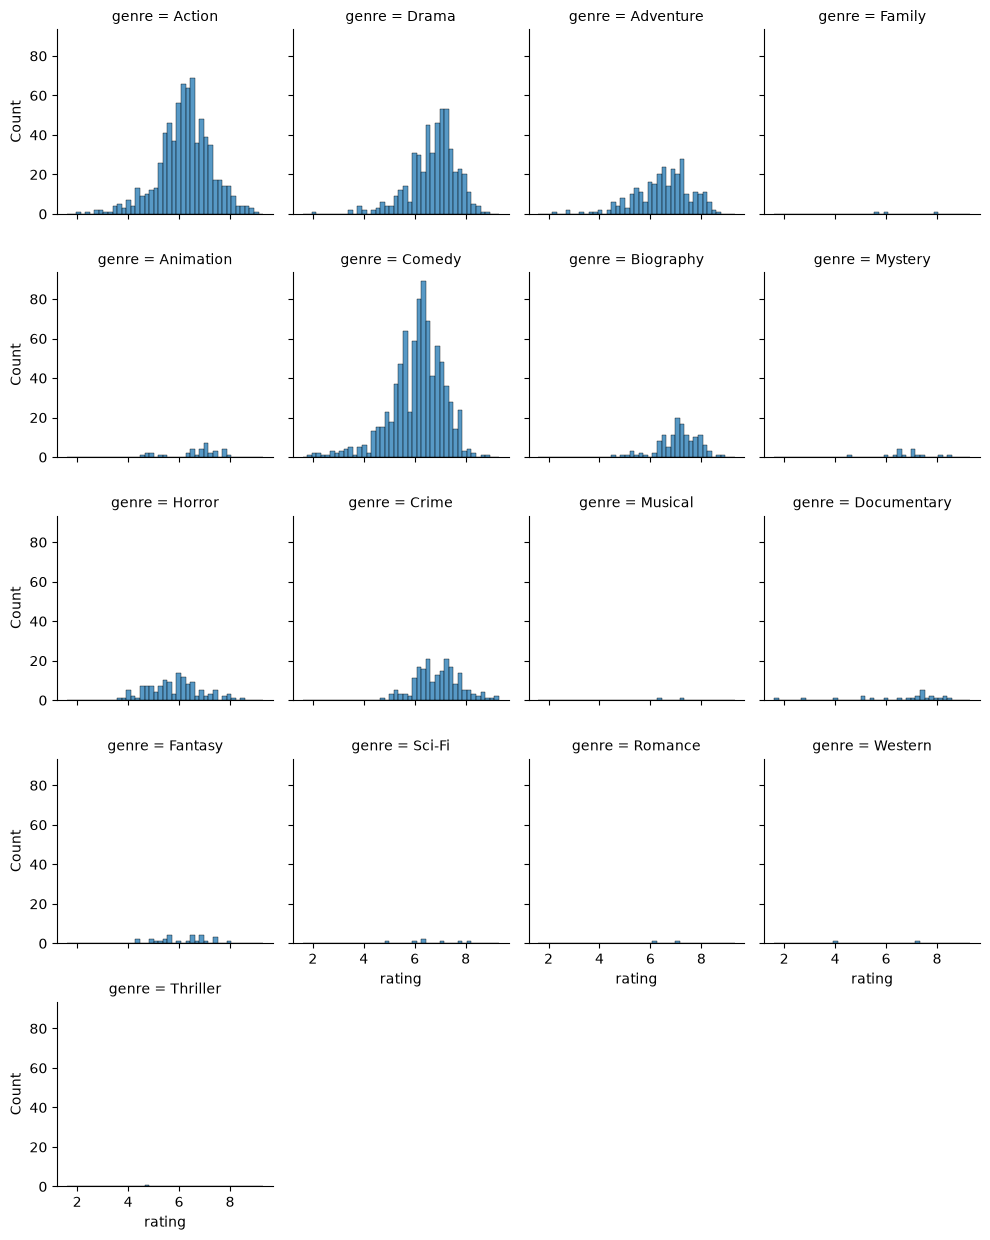

In [35]:
rating_distribution = (
    movies
    .groupby('genre')
    .agg(
        mean_rating= ('rating', 'mean'),
        min_rating= ('rating', 'min'),
        max_rating= ('rating', 'max'),
        median_rating= ('rating', 'median'),
        std_rating= ('rating', 'std')
    )
    .reset_index()
)

display(rating_distribution)

sns.displot(
    data=movies,
    x='rating',
    col='genre',
    col_wrap=4,
    kind='hist',
    height=2.5,
)
plt.show()

**Challenge - Produce a table of your own choosing, something you think is important/interesting to have data for, justify your result by writting a 2 sentence explanation/interpretation of the result.**

,year,mean_duration,min_duration,max_duration,median_duration,std_duration
0,1920,110.000000,110,110,110.0,NaN
1,1929,100.000000,100,100,100.0,NaN
2,1933,89.000000,89,89,89.0,NaN
3,1935,81.000000,81,81,81.0,NaN
4,1936,87.000000,87,87,87.0,NaN
...,...,...,...,...,...,...
64,2012,107.742424,80,173,103.0,19.513793
65,2013,112.480620,75,240,109.0,21.866463
66,2014,112.516949,81,170,109.0,18.602331
67,2015,112.117647,81,187,110.0,18.070979


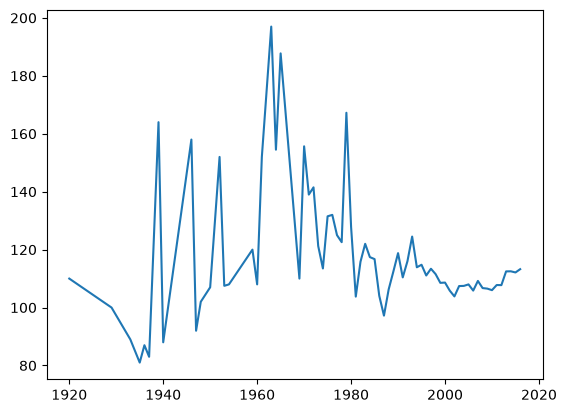

In [40]:
# I am really interested in the duration of the movies, expecially if there is any trend visible. For example with time people prefer, longer/shorter movies etc.
duration_data_per_year = (
    movies
    .groupby('year')
    .agg(
        mean_duration= ('duration', 'mean'),
        min_duration= ('duration', 'min'),
        max_duration= ('duration', 'max'),
        median_duration= ('duration', 'median'),
        std_duration= ('duration', 'std')
    )
    .reset_index()
)

display(duration_data_per_year)

plt.plot(
    duration_data_per_year['year'],
    duration_data_per_year['mean_duration']
)
plt.show()

#after plotting the data, the clear thing is that we would need more data per year, because this way the graph is so noisy
#however even like this, we can say that the mean usually tends to be between 100 and 120

#### Use visualisation to answer the following questions

**Examine the relationship between `gross` and `cast_facebook_likes`. Produce a scatterplot and write one sentence discussing whether the number of facebook likes that the cast has received is likely to be a good predictor of how much money a movie will make at the box office. What variable are you going to map to the Y- and X- axes?**

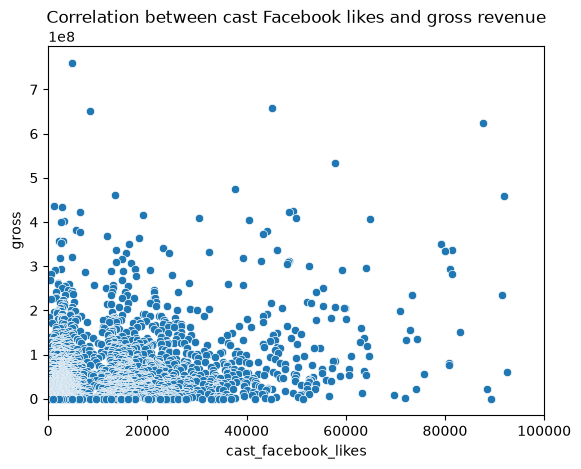

In [ ]:
sns.scatterplot(
    data=movies,
    x='cast_facebook_likes',
    y='gross'
)

plt.title('Correlation between cast Facebook likes and gross revenue')
plt.xlim(0, 100000)
plt.show()

#just for having a clearer view I limited the x axis
#gross goes on the y axis, because that is what we want to predict, and cast_facebook_likes goes to the x axis, becasue that is the predictor
#we can clearly say that there is no correlation between the two variables
#movies with a lot of likes can earn very few and movies with almost no likes can reach a very significant gross amount

**Examine the relationship between `gross` and `budget`. Produce a scatterplot and write one sentence discussing whether budget is likely to be a good predictor of how much money a movie will make at the box office.**

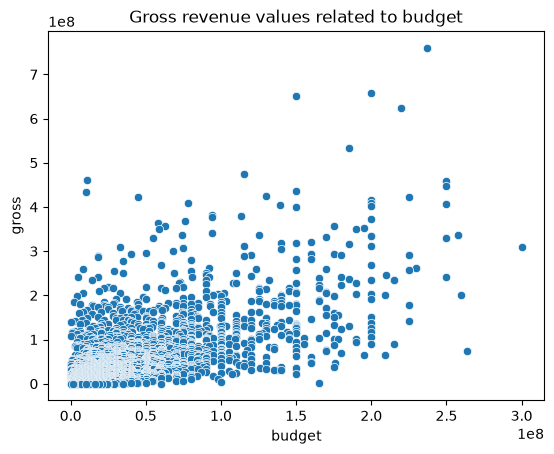

In [ ]:
# x axis: budget (predictor)
# y axis: gross (we want to predict it)

sns.scatterplot(
    data=movies,
    x='budget',
    y='gross'
)

plt.title("Gross revenue values related to budget")
plt.show()

#the data shows a minimal correlation. They are very scattered, but tend to follow a very broad line

**Examine the relationship between `gross` and `rating`. Produce a scatterplot, faceted by `genre` and discuss whether IMDB ratings are likely to be a good predictor of how much money a movie will make at the box office. Is there anything strange in this dataset?**

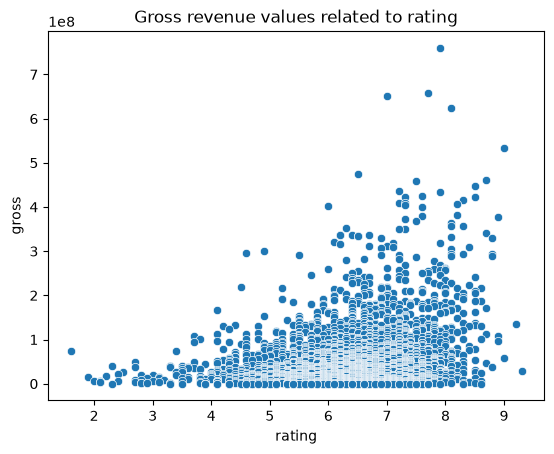

In [ ]:
# x axis: rating (predictor)
# y axis: gross (we want to predict it)

sns.scatterplot(
    data=movies,
    x='rating',
    y='gross'
)

plt.title("Overall gross revenue values related to rating")
plt.show()

#the dataset is stange, because the good earning movies tend to have a good rating
#however, a good rating doesn't means that the movie will have a high gross revenue
#so the rating is not a good predictor

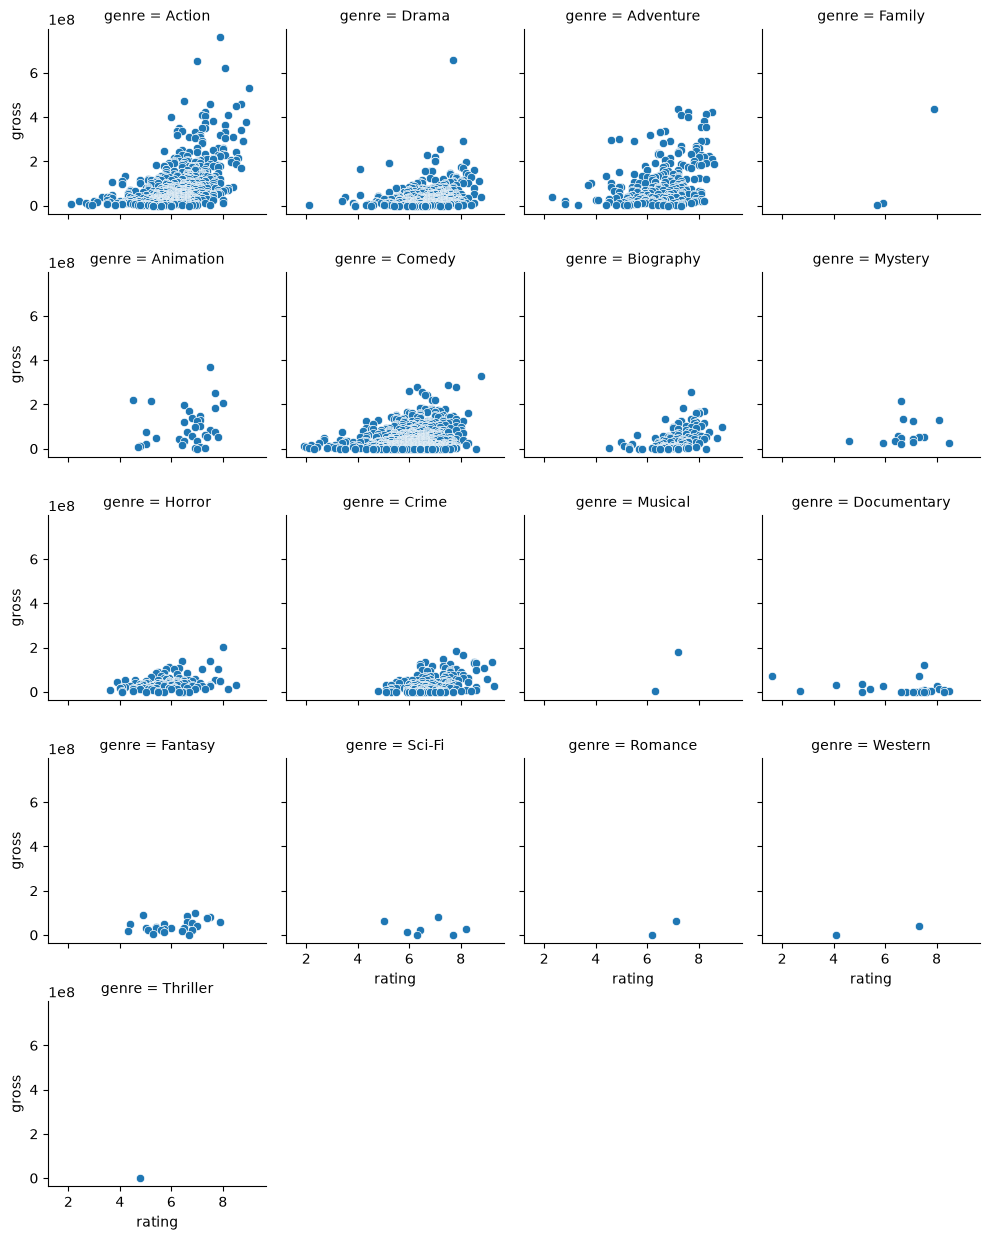

In [ ]:
sns.relplot(
    data=movies,
    x='rating',
    y='gross',
    col='genre',
    col_wrap=4,
    kind='scatter',
    height=2.5
)
plt.show()

#after checking faceted by genre I dont see strong correlations
#the only thing which can be interesting is that the highest earning movies have good rating and belong to the Action, Drama or Adventure genres

**Challenge - Produce a visualisation of your choosing, something you think is important to explore/investigate visually. Do make it a comprehensive graph and not a single histogram or density plot. Make it publication ready, label your axes, give it a title, choose colouring options, appropirately formatted text etc.**

,year,median_budget,q25,q75,n_movies
0,1920,0.1000,0.10000,0.10000,1
1,1929,0.3790,0.37900,0.37900,1
2,1933,0.4390,0.43900,0.43900,1
3,1935,0.6090,0.60900,0.60900,1
4,1936,1.5000,1.50000,1.50000,1
5,1937,2.0000,2.00000,2.00000,1
6,1939,3.3885,3.09425,3.68275,2
7,1940,2.6000,2.60000,2.60000,1
8,1946,5.0500,3.57500,6.52500,2
9,1947,2.3000,2.30000,2.30000,1


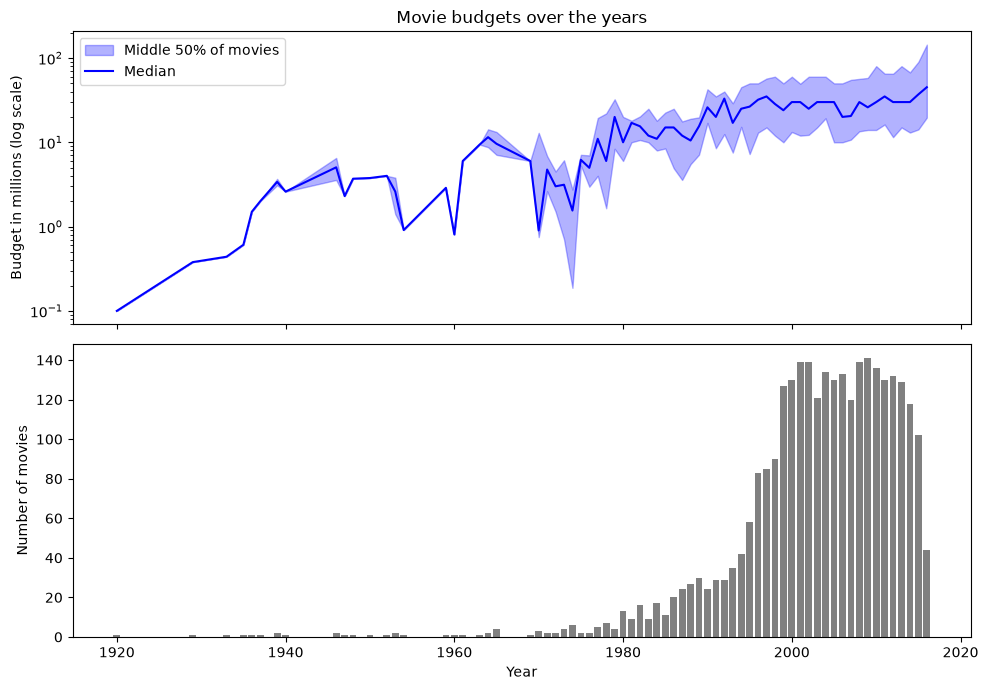

In [77]:
#I want to see how budgets chagned over the years

#filtering 0 budgets helps to have a clearer graph (I suppose zero budget is missing data)
plot_data = movies[movies['budget'] > 0].copy()

#to make things easier we count in millions
plot_data['budget_m'] = plot_data['budget'] / 1e6

budget_data_per_year = (
    plot_data
    .groupby('year')
    .agg(
        median_budget=('budget_m', 'median'),
        q25=('budget_m', lambda s: s.quantile(0.25)),
        q75=('budget_m', lambda s: s.quantile(0.75)),
        n_movies=('budget_m', 'size'),
    )
    .reset_index()
)

display(budget_data_per_year.head(10))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 7))

#panel 1 is showing how the budget is changing over the years
ax1.fill_between(budget_data_per_year['year'],
                 budget_data_per_year['q25'],
                 budget_data_per_year['q75'],
                 color='blue', alpha=0.3, label='Middle 50% of movies')
ax1.plot(budget_data_per_year['year'],
         budget_data_per_year['median_budget'],
         color='blue', label='Median')
ax1.set_yscale('log')
ax1.set_ylabel('Budget in millions (log scale)')
ax1.set_title('Movie budgets over the years')
ax1.legend()

# panel 2 is showing how many movies we have data of for each year
# helps us determine how trustable is the data
ax2.bar(budget_data_per_year['year'], budget_data_per_year['n_movies'], color='grey')
ax2.set_ylabel('Number of movies')
ax2.set_xlabel('Year')

fig.tight_layout()
plt.show()

### Deliverables

Poduce a clean, stand-alone notebook (or HTML export) with:

All tables/plots properly labeled

Brief interpretations where requested

Upload final HTML/Notebook.